# Introduction into Data Science - Assignment Part II

This is the second part of the assignment in IDS 2023/2024.

This part of the assignment consists of five questions — each of these questions is contained in a separate Jupyter notebook:
- [Question 1: Data Preprocessing](Q1_Preprocessing_Visualization.ipynb)
- [Question 2: Association Rules](Q2_Frequent_Itemsets_Association_Rules.ipynb)
- [Question 3: Process Mining](Q3_Process_Mining.ipynb)
- [Question 4: Text Mining](Q4_Text_Mining.ipynb)
- [Question 5: Big Data](Q5_Big_Data.ipynb)

Additional required files are in two folders.
- [datasets](datasets/)
- [scripts](scripts/)

Please use the provided notebook to work on the questions. When you are done, upload your version of each of the notebooks to Moodle. Your submission will, therefore, consist of five jupyter notebook and _no_ additional file. Any additionally provided files will not be considered in grading.
Enter your commented Python code and answers in the corresponding cells. Make sure to answer all questions in a clear and explicit manner and discuss your outputs. _Please do not change the general structure of this notebook_. You can, however, add additional markdown or code cells if necessary. Please **DO NOT CLEAR THE OUTPUT** of the notebook you are submitting! Additionally, please ensure that the code in the notebook runs if placed in the same folder as all of the provided files, delivering the same outputs as the ones you submit in the notebook. This includes being runnable in the bundled conda environment.

*Please make sure to include the names and matriculation numbers of all group members in the provided slots in each of the notebooks.* If a name or a student id is missing, the student will not receive any points.

Hint 1: **Plan your time wisely.** A few parts of this assignment may take some time to run. It might be necessary to consider time management when you plan your group work. Also, do not attempt to upload your assignment at the last minute before the deadline. This often does not work, and you will miss the deadline. Late submissions will not be considered.

Hint 2: RWTHMoodle allows multiple submissions, with every new submission overwriting the previous one. **Partial submissions are possible and encouraged.** This might be helpful in case of technical issues with RWTHMoodle, which may occur close to the deadline.

Hint 3: As a technical note. Some IDEs such as DataSpell may automatically strip jupyter notebook cell metadata. If you are able, please re-add it from the source notebooks before submission. This is necessary for our grading.

Enter your group number and members with matriculation numbers below.

In [1]:
GROUP_NO = 47 # group number
GROUP_MEMBERS = {
    460101: "Feiyu Wang", # mat. no. : name,
    460790: "Malte Schörken",
    461277: "Chenmingxuan Feng",
}

---

In [2]:
# required imports
# do not edit!

import nltk
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import unicodedata
import multiprocessing
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from nltk.corpus import stopwords
from nltk.lm import MLE
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.stem import WordNetLemmatizer
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')  # omw = open multilingual wordnet
stopword_list = set(stopwords.words('english'))
reg_tokenizer = nltk.RegexpTokenizer(r"\w+")  # tokenizes and removes punctuation at the same time
snow_stemmer = SnowballStemmer('english')
wordnet_lemmatizer = WordNetLemmatizer();

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\malte\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\malte\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\malte\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\malte\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Question 4: Text Mining (23 pts)


## About the Data: Taylor Swift

In this task, our data consists of song lyrics from nine albums by Taylor Swift. Taylor Swift is one of the best-selling musicians and currently subject of various research. As she is known to venture into different musical genres and make artistic innovations for each album, we want to check whether we can support this claim using Text Mining.

Therefore, we:
1. Load the data and preprocess it first,
2. use the set of words for recognizing a lyric's album,
3. use Doc2Vec to check the similarity of albums and to cluster them,
4. and finally use language models that are based on n-grams to generate some own lyrics.

We aim to support our data analysis by reporting data and discussing results. 

## Data Loading and Preprocessing (8 Pts)

### a)
i. First things first. Import the file **q4_taylor_swift.csv** and save it into a dataframe named `swift_df`. Visualize the dataframe by showing the first five lines. 

_Note: In this question, every lyric is considered as a single document. The data contains lyrics from several albums. The order of the lyrics is preserved considering their album, song and within their song._


In [3]:
# Import and visualization.
# YOUR CODE HERE

swift_df = pd.read_csv('datasets/q4_taylor_swift.csv')
print(swift_df.head())

          album                                        lyric
0  Taylor Swift          He said the way my blue eyes shined
1  Taylor Swift  Put those Georgia stars to shame that night
2  Taylor Swift                       I said, "That's a lie"
3  Taylor Swift                  Just a boy in a Chevy truck
4  Taylor Swift         That had a tendency of gettin' stuck


ii. As a first step in preprocessing, normalize all unicode encodings using `unicodedata.normalize` with 'NKFD' as the form and remove all closing and opening brackets, i.e., '(' and ')'.

In [4]:
# YOUR CODE HERE
swift_df['lyric'] = swift_df['lyric'].apply(lambda x: unicodedata.normalize('NFKD', x))
swift_df['lyric'] = swift_df['lyric'].str.replace('(', '').replace(')', '')
print(swift_df.head())

          album                                        lyric
0  Taylor Swift          He said the way my blue eyes shined
1  Taylor Swift  Put those Georgia stars to shame that night
2  Taylor Swift                       I said, "That's a lie"
3  Taylor Swift                  Just a boy in a Chevy truck
4  Taylor Swift         That had a tendency of gettin' stuck


### b)
We get a first idea of the data distribution over the albums by counting the lyrics in our data per album. Code the method `count_lyrics_per_album`.

In [5]:
def count_lyrics_per_album(input_df: pd.DataFrame) -> pd.Series:
    """ 
    Counts the lyrics for each album and stores them in a pandas series.
    :param input_df: A pandas dataframe containing album data and their lyrics.
    :return: The data containing the albums and the count of lyrics per album.
    """
    # YOUR CODE HERE
    lyrics_count = input_df.groupby('album')['lyric'].count()
    return lyrics_count

In [6]:
# Using the predefined function to calculate the series of values
count_per_album = count_lyrics_per_album(swift_df)

# Transforming the series to a dataframe for visualization - feel free to check the series object
pd.DataFrame({'album': count_per_album.index, 'lyric count': count_per_album.values})

,album,lyric count
0,1989 (Deluxe),1003
1,Fearless (Taylor’s Version),1170
2,Lover,932
3,Red (Deluxe Edition),1064
4,Speak Now (Deluxe),935
5,Taylor Swift,609
6,evermore (deluxe version),909
7,folklore (deluxe version),722
8,reputation,985


### c)
i. Next, we visualize the counted lyrics per album using a barplot. Write down your code in `plot_lyric_count`.

In [7]:
def plot_lyric_count(input_series: pd.Series):
    """ 
    Visualizes the number of lyrics for each album in a bar plot.
    :param input_series: A pandas series containing album data and their lyric counts.
    """
    # YOUR CODE HERE
    
    sns.barplot(x=input_series.index, y=input_series.values)
    mpl.pyplot.ylabel('Lyric Count')
    mpl.pyplot.xticks(rotation=45, ha='right')
    mpl.pyplot.show()

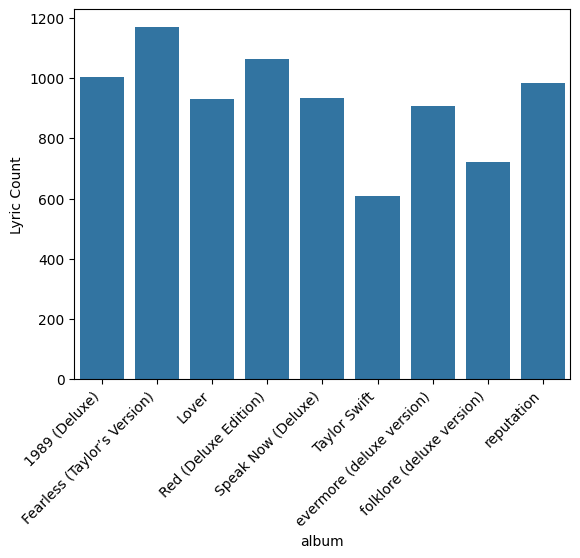

In [8]:
# Visualizing the data of 'count_per_album' as a bar plot using your function
plot_lyric_count(count_per_album)

ii. Is the data balanced enough for album classification?

__Student Answer:__ We can see some imbalance with Taylor Swift having about 600 and Fearless almost 1200 data points. Nevertheless this should still be balanced enough for classification.

### d)
In the following, we want to remove duplicate lyrics, as a song may contain a lyric more than once. Removing duplicates improves the interpretability of the further analysis and reduces an overfitting of the classification task on the duplicated lyrics. 

i. Therefore, as a first step, we remove all duplicate lyrics and keep only a single instance per duplicate lyric on each album. The obtained dataset has to be named `swift_df_proc`.

In [9]:
# Dropping all duplicates of a lyric on an album
# YOUR CODE HERE
swift_df_proc = swift_df.drop_duplicates(subset=['album', 'lyric'])
print(swift_df_proc.head())

          album                                        lyric
0  Taylor Swift          He said the way my blue eyes shined
1  Taylor Swift  Put those Georgia stars to shame that night
2  Taylor Swift                       I said, "That's a lie"
3  Taylor Swift                  Just a boy in a Chevy truck
4  Taylor Swift         That had a tendency of gettin' stuck


ii. Do lyrics occur in several albums? If this is the case, remove them entirely as such a lyric is not suitable for our further questions. If this is not the case, give the code that shows so. Remember also to give a clear answer below. 

In [10]:
# YOUR CODE HERE
duplicated_lyrics = swift_df_proc[swift_df_proc.duplicated(subset=['lyric'], keep=False)]
print(len(duplicated_lyrics))
swift_df_proc = swift_df_proc.drop_duplicates(subset=['lyric'], keep=False)
print(swift_df_proc.head())

26
          album                                        lyric
0  Taylor Swift          He said the way my blue eyes shined
1  Taylor Swift  Put those Georgia stars to shame that night
2  Taylor Swift                       I said, "That's a lie"
3  Taylor Swift                  Just a boy in a Chevy truck
4  Taylor Swift         That had a tendency of gettin' stuck


__Student Answer:__ Yes there are 33 cases where a lyric appears more than once. These were deleted.

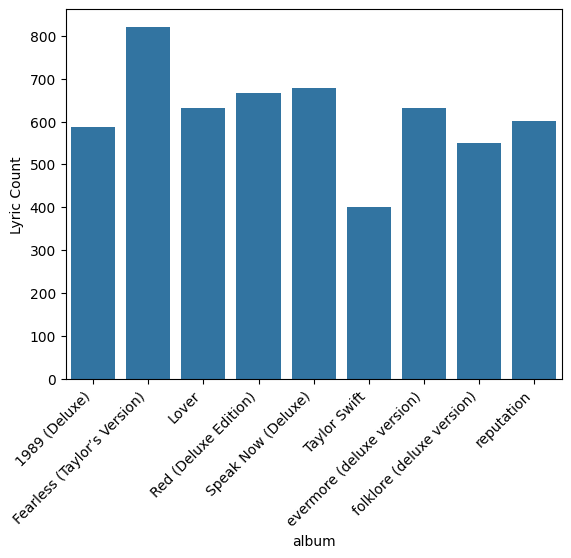

album
1989 (Deluxe)                  588
Fearless (Taylor’s Version)    820
Lover                          631
Red (Deluxe Edition)           666
Speak Now (Deluxe)             679
Taylor Swift                   400
evermore (deluxe version)      632
folklore (deluxe version)      549
reputation                     601
Name: lyric, dtype: int64

In [11]:
plot_lyric_count(count_lyrics_per_album(swift_df_proc))
count_lyrics_per_album(swift_df_proc)

### e)
The following tasks are more related to the preprocessing that has to be applied for the Text Mining context. First of all, we have to create a corpus. The obtained corpus should be named `corpus`. Make sure that each document in the corpus corresponds to exactly one lyric in `swift_df_proc`. 

In [12]:
# Creating the corpus
# YOUR CODE HERE
corpus = swift_df_proc['lyric'].tolist()

### f)
Use the skeleton of the function `preprocessor_func` below to create a function that applies tokenization, stopword removal and lemmatization to an input string. The remaining tokens (after stopword removal and lemmatization) should be joined using a whitespace (' ').

_Note: To keep the complexity low, we do not expect you to use POS tagging before lemmatizing. You can apply lemmatization only for the nouns. This is covered by using a lemmatizer without further arguments._

In [13]:
def preprocessor_func(text: str) -> str:
    """
    Preprocesses a string using tokenization, stopword removal and lemmatization.
    :param text: A string to be preprocessed.
    :return: A joined string resulting from tokenization, stopword removal and lemmatization of an input string.
    """
    # YOUR CODE HERE
    tokenizer = nltk.RegexpTokenizer(r"\w+")
    stop_list = stopwords.words("english")
    lemmatizer = WordNetLemmatizer()
    
    # Tokenize
    tokenized = tokenizer.tokenize(text)
    # Filter stop words
    filtered = [word.lower() for word in tokenized if word.lower() not in stop_list]
    # Stem remaining tokens
    lemmatized = [lemmatizer.lemmatize(word) for word in filtered]

    return ' '.join(lemmatized)
    

### g)
Now, create a preprocessed corpus `corpus_proc` by applying the preprocessing function to your corpus. For some tasks, we have to use the preprocessed corpus, and for some, the original corpus. This is indicated for each task.

In [14]:
# Corpus preprocessing
# YOUR CODE HERE
# Putting the non-empty strings into the corpus
corpus_proc = [preprocessor_func(lyric) for lyric in corpus if preprocessor_func(lyric)]
corpus_proc = [preprocessor_func(lyric) for lyric in corpus]
corpus_proc[:5]

['said way blue eye shined',
 'put georgia star shame night',
 'said lie',
 'boy chevy truck',
 'tendency gettin stuck']

### h)
In this task, we create all preprocessed data for all remaining tasks within the Text Mining question exercise.
For the later application of the set of words, we need to split the corpus.
First, we need to split our input data into a train and test set according to the Pareto rule (80% training set size and 20% test set size).
Therefore, split the dataframe `swift_df_proc` into a training and test set using the variable identifiers `df_train`, `df_test`, `y_train`, and `y_test`.
Further, make sure that distribution based on the "album" value is preserved.

In [15]:
# YOUR CODE HERE
X = swift_df_proc['lyric']
y = swift_df_proc['album']

df_train, df_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### i)
Lastly, we create two further corpora, `corpus_train` and `corpus_test`, using the split data and the identical approach that is used before.

In [16]:
# YOUR CODE HERE
corpus_train = [preprocessor_func(lyric) for lyric in df_train]
corpus_test = [preprocessor_func(lyric) for lyric in df_test]

corpus_test[:5]

['getting caught moment',
 'without knowing anything',
 'starin sunset babe',
 'supposed talk',
 'real enough whether weather frost']

## Set of Words (6.5 Pts)

In this subtask, we use the set of words technique to distinguish and recognize different lyrics based on which album they belong to. Set of words encodes the documents by indicating for each word in our vocabulary whether the word occurs in the sentence or not.

### j)
Create a set of words encoding for the whole corpus. Use the previously defined preprocessor function `preprocessor_func` for our corpus `corpus`. 

In [17]:
# Creating a set of words using the propressor function and the corpus
# YOUR CODE HERE
sow = CountVectorizer(binary=True, preprocessor=preprocessor_func)
corpus_sow = sow.fit_transform(corpus).toarray()

### k)
In the following, we want to have a first look at how the set of words classification works. Therefore, we apply the set of words to a line in the `swift_df`. Use the `apply_sow_to_line_by_index` function that is given an index of a lyric and that returns the original line, its preprocessed form, and its encoding resulting from the set of words implementation.
Comment below on what information the set of words representation contains.

In [18]:
def apply_sow_to_lyric_by_index(index: int) -> (str, str, _):
    """ 
    Applies set of words to a lyric in the swift_df.
    :param index: The index of the chosen lyric entry.
    :return: The function returns the chosen lyric, it preprocessed form and the set of words representation. 
    """
    # YOUR CODE HERE
    lyric = swift_df.iloc[index]['lyric']
    lyric_p = preprocessor_func(lyric)
    lyric_sow = sow.transform([lyric_p]).toarray()
    
    return lyric, lyric_p, lyric_sow

In [19]:
# YOUR CODE HERE
index = 0

In [20]:
line, line_p, line_sow = apply_sow_to_lyric_by_index(index)
print('Original line:     ', line)
print('Preprocessed line: ', line_p)
print('SoW encoding:\n', line_sow)

Original line:      He said the way my blue eyes shined
Preprocessed line:  said way blue eye shined
SoW encoding:
 [[0 0 0 ... 0 0 0]]


__Student Answer:__ It is a binary array (values 0 or 1) indicating whether is word is present in the preprocessed lyrics or not.

### l)
In this subtask, we use a **S**tochastic **G**radient **D**escent classifier to predict the album given a lyric for the corpus. Therefore, the steps to follow are briefly described below:
 1. First, we create a set of words encoding for the whole corpus. As we want to evaluate our results later using the test set, restrict yourself in the training to only use the training set `corpus_train`. 
 2. Train the classifier on the training set with 'album' as the target feature and 'log_loss' as the loss function.
 3. Predict the album for each line in the training and test set `corpus_test`.
 4. Calculate and show the accuracy for both the training and test set and store them in the variables `accuracy_train` and `accuracy_test`.

In [21]:
# Creating the set of words encoding
# YOUR CODE HERE

sow = CountVectorizer(binary=True, preprocessor=preprocessor_func)
X_train = sow.fit_transform(corpus_train)
X_test = sow.transform(corpus_test)

In [22]:
# Train the classifier
# YOUR CODE HERE
classifier = SGDClassifier(loss='log_loss')
classifier.fit(X_train, y_train)

SGDClassifier(loss='log_loss')

In [23]:
# Predict the album
# YOUR CODE HERE
y_train_pred = classifier.predict(X_train)
y_test_pred = classifier.predict(X_test)

In [24]:
# Compute and show accuracy for training and test set
# YOUR CODE HERE
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)
print("Accuracy on Training Set:", accuracy_train)
print("Accuracy on Test Set:", accuracy_test)

Accuracy on Training Set: 0.7630278526504941
Accuracy on Test Set: 0.3213644524236984


### m)
Given the accuracy values that you calculated in the last subtask, argue about the classifier's accuracy compared to a most frequent guessing classifier (i.e., a classifier that always chooses to predict the most frequent album). Use the distribution of lyrics over the albums calculated in task **d)** to support your argument. 

__Student Answer:__ The most frequent album is "Fearless (Taylor’s Version)" with 818 lyrics in the preprocessed dataframe. This corresponds to about 14.8% of the total lyrics. Therefore a most frequent guesser would be ecpected to have an accuracy of about 14.8% on the test set while the trained SGD Classifier has an accuracy of about 32. Although the accuracy is significantly higher than the most frequent guesser it is still bad and most likely not useful in practical applications.

### n)
Next, we want to make our results more visual. Therefore, implement the `pred_album_by_index` method that takes a lyric's index from the `swift_df` dataframe as input, and based on that, returns the corresponding lyric, its actual album and its predicted album using the SGD classifier from **l)**.

In [25]:
def pred_album_by_index(index: int) -> (str, str, str):
    """ 
    Predicts a lyric's album based on the .
    :param index: The index of the chosen lyric entry.
    :return: The function returns the chosen lyric, it preprocessed form and the set of words representation. 
    """
    # YOUR CODE HERE
    lyric = swift_df.iloc[index]['lyric']
    album_true = swift_df.iloc[index]['album']

    lyric_p = preprocessor_func(lyric)
    lyric_sow = sow.transform([lyric_p]).toarray()
    album_pred = classifier.predict(lyric_sow)[0]

    return lyric, album_true, album_pred

In [26]:
index = 0 # Please change the index and do not use -1

In [27]:
lyric, album_actual, album_pred = pred_album_by_index(index)

print("Lyric:          ", lyric)
print("Actual album:   ", album_actual)
print("Predicted album:", album_pred)

Lyric:           He said the way my blue eyes shined
Actual album:    Taylor Swift
Predicted album: Taylor Swift


## Doc2Vec (4.5 pts)

In this subtask, we encode lyrics using Doc2Vec. Given the embedding, we reduce its dimensionality using **P**rincipal **C**omponent **A**nalysis while preserving the maximum amount of information so that we can visualize and cluster the embeddings in a scatter plot. Lastly, we have a manual look at the clusters to evaluate the information gain of the Doc2Vec approach.

### o) 
Initialize and train a Doc2Vec model based on the documents in the preprocessed corpus `corpus_p`. Set `epochs=100` for the training of the model. Set the vector dimension to 20 and min_count to 3.

In [28]:
# Calculating the number of cores available
cores = multiprocessing.cpu_count()

# YOUR CODE HERE

# The preprocessed corpus in this assignment was called corpus_proc, corpus_p was in the exercises
docs = [TaggedDocument(doc, [i]) for i, doc in enumerate(corpus_proc)]
doc2vec = Doc2Vec(vector_size=20, min_count=3, workers=cores)
doc2vec.build_vocab(docs)
doc2vec.train(docs, total_examples=doc2vec.corpus_count, epochs=100)

### p)
Create an embedding for each lyric in `swift_df_proc` and add all embeddings inferred to the `lyric_embeddings` list. This is a pretask for the next step that we take. 

In [29]:
lyric_embeddings = []
# YOUR CODE HERE

tokenizer = nltk.RegexpTokenizer(r"\w+")
lyric_embeddings = [doc2vec.infer_vector(tokenizer.tokenize(lyric)) for lyric in corpus_proc]

### q)
Store the data contained in `lyric_embeddings` in a dataframe `embeddings_df`.
Apply DBSCAN with euclidean distance to the `embeddings_df`dataframe with `eps = 0.3` and `min_samples = 2` and create a scatterplot with seaborn that shows the clusters of the inferred vectors. To be able to visualize the data in a two-dimensional vector space, apply a **p**rinciple **c**omponent **a**nalysis that is able to reduce the dimensionality of input data. (You can learn more about the PCA in its [Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)). The code for the PCA is provided.

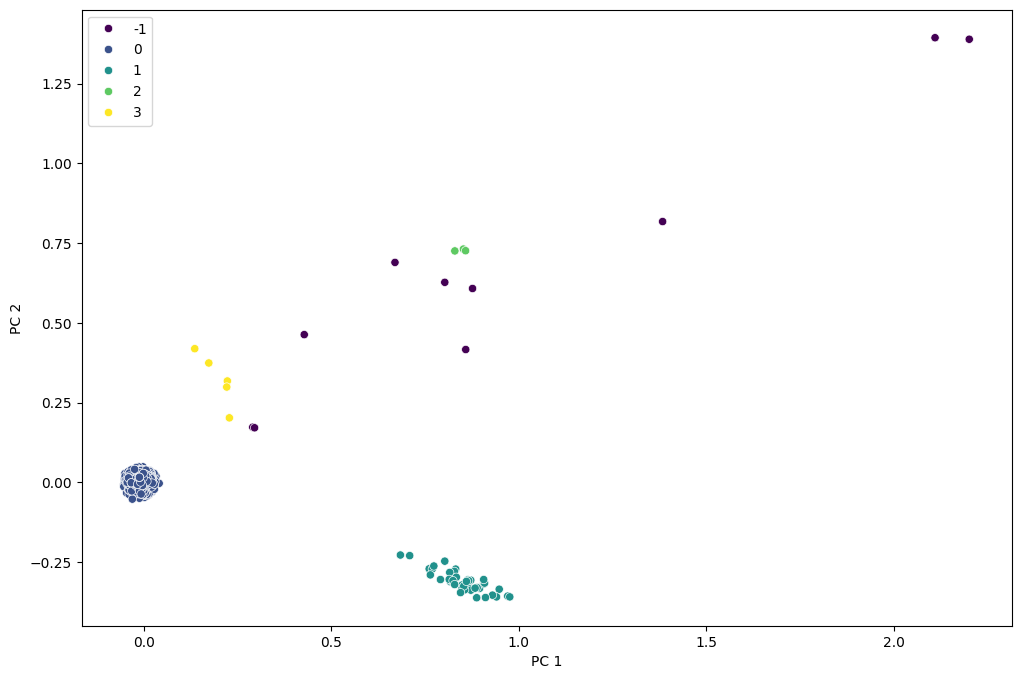

In [30]:
# YOUR CODE HERE
import matplotlib.pyplot as plt
import numpy as np

embeddings_df = pd.DataFrame(lyric_embeddings)
dbscan = DBSCAN(eps = 0.3, min_samples = 2)
clusters = dbscan.fit_predict(embeddings_df)

# Applying PCA to the embedding reducing the dimensionality to two
pca = PCA(n_components=2)
pca_embeddings = pd.DataFrame(pca.fit_transform(embeddings_df))

# YOUR CODE HERE
plt.figure(figsize=(12, 8))
sns.scatterplot(x=pca_embeddings[0], y=pca_embeddings[1], hue=clusters, palette='viridis', legend='full')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

### r)
Show lyrics from the original `swift_df` dataframe contained in two distinct clusters using the two cells below. Answer separately, whether you consider the lyrics in each cluster to be similar or dissimilar.

_Note: You do not have to find exactly two clusters. Having at least two clusters, you should show the lyrics from two distinct clusters._ 

In [31]:
# Lyrics contained in one cluster
# YOUR CODE HERE

print("Lyrics from Cluster 2:")
cluster_2_indices = np.where(clusters == 2)[0]
for index in cluster_2_indices:
    print(swift_df_proc['lyric'].iloc[index])

Lyrics from Cluster 2:
It's 2 A.M., feeling like I just lost a friend
And I remember that fight, 2:30 AM
It's 2 AM in my room


In [32]:
# Lyrics contained in one cluster
# YOUR CODE HERE

print("Lyrics from Cluster 3:")
cluster_3_indices = np.where(clusters == 3)[0]
for index in cluster_3_indices:
    print(swift_df_proc['lyric'].iloc[index])

Lyrics from Cluster 3:
Me-e-e, ooh-ooh-ooh-ooh
And I promise that nobody's gonna love you like me-e-e
Me-e-e Yeah), ooh-ooh-ooh-ooh And I want ya, baby)
I hit the Sunday matinée
And the town said, "How did a middle-class divorcée do it?"


__Student Answer:__ The result changes because there is randomness involved. However the lyrics in a cluster tend to have a similarity. For example in this cluster 2 we have we have the number 2 in all lyrics. This can be seen in the saved output but changes when the notebook is run again. We have to be careful with this assessment because the cluster 0 contains almost all the lyrics. Therefore there can't be much similarity in this very large cluster.

## An N-Gram Based Language Model (4 Pts)

In this subtask, we use the `swift_df` data to create an n-gram based language model to generate new lyrics. Therefore, we play around with different values for n.

### s)
Write the `lyric_preprocessor` method that takes a lyric as input and that tokenizes it and makes each word lowercase.

In [33]:
def lyric_preprocessor(lyric: str) -> [str]:
    """
    Tokenizes a lyric and makes the tokens lowercase.
    :param lyric: A string containing an we can input lyric.
    :return: A list containing lowercase tokens of the input lyric.
    """
    # YOUR CODE HERE
    
    tokenized = tokenizer.tokenize(lyric)
    lowercase_tokens = [token.lower() for token in tokenized]
    return lowercase_tokens

### t)
Apply the lyric_preprocessor to all lyrics in the `swift_df` and store the data in a `lyric_corpus` variable.

In [34]:
# YOUR CODE HERE
lyric_corpus = swift_df['lyric'].apply(lyric_preprocessor)

Next, train two n-grams with $n \in \{2,5\}$ on the lyric_corpus.

In [35]:
# YOUR CODE HERE
padded_tuples, vocab = padded_everygram_pipeline(2, lyric_corpus)
lm_2 = MLE(2)
lm_2.fit(padded_tuples, vocab)
padded_tuples, vocab = padded_everygram_pipeline(5, lyric_corpus)
lm_5 = MLE(5)
lm_5.fit(padded_tuples, vocab)

### u)
i. Write the `generate_lyrics` method that takes an n-gram model and an integer for the number of lyrics to be generated as input and that returns a list of new lyrics that were generated using the given n-gram model.

_Reminder / Hints: A lyric generated by an n-gram starts with n-1 times the start token "\<s>" and ends with n-1 times the end token "\</s>". Further, the n value of an n-gram can be accessed using the `n-gram.order` variable of an `n-gram`. Additionally keep in mind that you can condition the generation of your n-gram on some preceding text._

In [36]:
def generate_lyrics(n_gram_model, numb_of_new_lyrics: int) -> [str]:
    """
    Uses an n-gram model to generate several new lyrics.
    :param n_gram_model: An n-gram model. 
    :param numb_of_new_lyrics: The number of lyrics to be created.
    :return: As many generated lyrics as defined by the numb_of_new_lyrics.
    """
    # YOUR CODE HERE
    generated_lyrics = []
    start_token = ["<s>"] * (n_gram_model.order - 1)
    end_token = ["</s>"] * (n_gram_model.order - 1)

    for _ in range(numb_of_new_lyrics):
        current_text = start_token.copy()
        while True:
            context = list(current_text[-(n_gram_model.order - 1):])
            next_word = n_gram_model.generate(text_seed=context)
            if next_word == "</s>":
                break
            current_text.append(next_word)
        current_text.append(" ".join(end_token))

        generated_lyric = " ".join(current_text)
        generated_lyrics.append(generated_lyric)

    return generated_lyrics
    
    

ii. Generate with the first and the second model ten lyrics each. Name one difference that you can find between the lyrics generated with 2-gram model and with the 5-gram model.

In [37]:
# Generate and show ten lyrics with the first model
# YOUR CODE HERE
generated_lyrics_2gram = generate_lyrics(lm_2, 10)
print("Generated Lyrics with 2-gram Model:")
for i, lyric in enumerate(generated_lyrics_2gram, start=1):
    print(f"{i}. {lyric}\n")

Generated Lyrics with 2-gram Model:
1. <s> run </s>

2. <s> and that you re made mistakes in the hell you didn t let you </s>

3. <s> and if you can be cleaning up when i just maybe get you d you took him tight to kill my flaws </s>

4. <s> to hang your face </s>

5. <s> but i meant to be standing in my shoulders is difficult but i could take it cut </s>

6. <s> so i ve loved you </s>

7. <s> distance timing breakdown fighting </s>

8. <s> you find stealing other </s>

9. <s> you babe if you i like this </s>

10. <s> i can t wait </s>



In [38]:
# Generate and show ten lyrics with the first model
# YOUR CODE HERE
generated_lyrics_5gram = generate_lyrics(lm_5, 10)
print("\nGenerated Lyrics with 5-gram Model:")
for i, lyric in enumerate(generated_lyrics_5gram, start=1):
    print(f"{i}. {lyric}\n")


Generated Lyrics with 5-gram Model:
1. <s> <s> <s> <s> whoa holding my breath </s> </s> </s> </s>

2. <s> <s> <s> <s> i check it once then i check it twice oh </s> </s> </s> </s>

3. <s> <s> <s> <s> than i was at 16 lost in a film scene </s> </s> </s> </s>

4. <s> <s> <s> <s> and when you take you take the very best of me </s> </s> </s> </s>

5. <s> <s> <s> <s> this ain t the best view </s> </s> </s> </s>

6. <s> <s> <s> <s> breathe without you but i have to </s> </s> </s> </s>

7. <s> <s> <s> <s> everything will be alright if we just keep dancing like we re </s> </s> </s> </s>

8. <s> <s> <s> <s> don t know why but with you i d dance </s> </s> </s> </s>

9. <s> <s> <s> <s> all that i know is </s> </s> </s> </s>

10. <s> <s> <s> <s> baby i m never gonna leave you </s> </s> </s> </s>



__Student Answer:__ In the 5-gram model the lyrics seem coherent. They seem like actual sentences while in the 2-gram model different parts of the same lyric seem completely unrelated.